<a href="https://colab.research.google.com/github/ekaratnida/social-network/blob/main/workshop/9_Link_Prediction_on_MovieLens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import Tensor
print(torch.__version__)

2.11.0+cu128


In [2]:
# Install required packages.
import os
os.environ['TORCH'] = torch.__version__

!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install pyg-lib -f https://data.pyg.org/whl/nightly/torch-${TORCH}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git

Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 34.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 48.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/nightly/torch-2.11.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 28.3 MB/s eta 0:00:00
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-stn5qfy9
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-stn5qfy9
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit 1f0661ce88272d03f654b6bb0a2a3cb76b3e6aff
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch-geometric: filename=torch_geometric-2.9.0-py3-none-any.

# Link Prediction on MovieLens

This colab notebook shows how to load a set of `*.csv` files as input and construct a heterogeneous graph from it.
We will then use this dataset as input into a [heterogeneous graph model](https://pytorch-geometric.readthedocs.io/en/latest/notes/heterogeneous.html#hgtutorial), and use it for the task of link prediction.
A few code cells require user input to let the code run through successfully.
If you are stuck on cells that require input, take a look at the fully filled out tutorial [here](https://medium.com/@pytorch_geometric/link-prediction-on-heterogeneous-graphs-with-pyg-6d5c29677c70).

We are going to use the [MovieLens dataset](https://grouplens.org/datasets/movielens/) collected by the GroupLens research group.
This toy dataset describes ratings and tagging activity from MovieLens.
The dataset contains approximately 100k ratings across more than 9k movies from more than 600 users.
We are going to use this dataset to generate two node types holding data for movies and users, respectively, and one edge type connecting users and movies, representing the relation of whether a user has rated a specific movie.

The link prediction task then tries to predict missing ratings, and can, for example, be used to recommend users new movies.

## Heterogeneous Graph Creation

First, we download the dataset to an arbitrary folder (in this case, the current directory):

In [3]:
from torch_geometric.data import download_url, extract_zip

url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
extract_zip(download_url(url, '.'), '.')

movies_path = './ml-latest-small/movies.csv'
ratings_path = './ml-latest-small/ratings.csv'

Extracting ./ml-latest-small.zip


Before we create the heterogeneous graph, let’s take a look at the data.

In [4]:
import pandas as pd

print('movies.csv:')
print('===========')
print(pd.read_csv(movies_path)[["movieId", "genres"]].head())
print()
print('ratings.csv:')
print('============')
print(pd.read_csv(ratings_path)[["userId", "movieId"]].head())

movies.csv:
   movieId                                       genres
0        1  Adventure|Animation|Children|Comedy|Fantasy
1        2                   Adventure|Children|Fantasy
2        3                               Comedy|Romance
3        4                         Comedy|Drama|Romance
4        5                                       Comedy

ratings.csv:
   userId  movieId
0       1        1
1       1        3
2       1        6
3       1       47
4       1       50


We see that the `movies.csv` file provides two useful columns: `movieId` assigns a unique identifier to each movie, while the `genres` column represent genres of the given movie.
We can make use of this column to define a feature representation that can be easily interpreted by machine learning models.

In [5]:
# Load the entire movie data frame into memory:
movies_df = pd.read_csv(movies_path, index_col='movieId')

# Split genres and convert into indicator variables:
genres = movies_df['genres'].str.get_dummies('|')
print(genres.head())
#print(genres[["Action", "Adventure", "Drama", "Horror"]].head())

# Use genres as movie input features:
movie_feat = torch.from_numpy(genres.values).to(torch.float)
assert movie_feat.size() == (9742, 20)  # 20 genres in total.

         (no genres listed)  Action  Adventure  Animation  Children  Comedy  \
movieId                                                                       
1                         0       0          1          1         1       1   
2                         0       0          1          0         1       0   
3                         0       0          0          0         0       1   
4                         0       0          0          0         0       1   
5                         0       0          0          0         0       1   

         Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  IMAX  Musical  \
movieId                                                                         
1            0            0      0        1          0       0     0        0   
2            0            0      0        1          0       0     0        0   
3            0            0      0        0          0       0     0        0   
4            0            0      1       

The `ratings.csv` data connects users (as given by `userId`) and movies (as given by `movieId`).
Due to simplicity, we do not make use of the additional `timestamp` and `rating` information.
Here, we first read the `*.csv` file from disk, and create a mapping that maps entry IDs to a consecutive value in the range `{ 0, ..., num_rows - 1 }`.
This is needed as we want our final data representation to be as compact as possible, *e.g.*, the representation of a movie in the first row should be accessible via `x[0]`.

Afterwards, we obtain the final `edge_index` representation of shape `[2, num_ratings]` from `ratings.csv` by merging mapped user and movie indices with the raw indices given by the original data frame.

In [33]:
# Load the entire ratings data frame into memory:
ratings_df = pd.read_csv(ratings_path)
print(ratings_df.head())

# Create a mapping from unique user indices to range [0, num_user_nodes):
unique_user_id = ratings_df['userId'].unique()
unique_user_id = pd.DataFrame(data={
    'userId': unique_user_id,
    'mappedID': pd.RangeIndex(len(unique_user_id)),
})
print("Mapping of user IDs to consecutive values:")
print("==========================================")
print(unique_user_id.head())
print()
# Create a mapping from unique movie indices to range [0, num_movie_nodes):
unique_movie_id = pd.DataFrame(data={
    'movieId': movies_df.index,
    'mappedID': pd.RangeIndex(len(movies_df)),
})
print("Mapping of movie IDs to consecutive values:")
print("===========================================")
print(unique_movie_id.head())

# Perform merge to obtain the edges from users and movies:
ratings_user_id = pd.merge(ratings_df['userId'], unique_user_id,
                            left_on='userId', right_on='userId', how='left')
ratings_user_id = torch.from_numpy(ratings_user_id['mappedID'].values)
ratings_movie_id = pd.merge(ratings_df['movieId'], unique_movie_id,
                            left_on='movieId', right_on='movieId', how='left')
ratings_movie_id = torch.from_numpy(ratings_movie_id['mappedID'].values)

# With this, we are ready to construct our `edge_index` in COO format
# following PyG semantics:
edge_index_user_to_movie = torch.stack([ratings_user_id, ratings_movie_id], dim=0)
assert edge_index_user_to_movie.size() == (2, 100836)

print()
print("Final edge indices pointing from users to movies:")
print("=================================================")
print(edge_index_user_to_movie)

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
Mapping of user IDs to consecutive values:
   userId  mappedID
0       1         0
1       2         1
2       3         2
3       4         3
4       5         4

Mapping of movie IDs to consecutive values:
   movieId  mappedID
0        1         0
1        2         1
2        3         2
3        4         3
4        5         4

Final edge indices pointing from users to movies:
tensor([[   0,    0,    0,  ...,  609,  609,  609],
        [   0,    2,    5,  ..., 9462, 9463, 9503]])


With this, we are ready to initialize our `HeteroData` object and pass the necessary information to it.
Note that we also pass in a `node_id` vector to each node type in order to reconstruct the original node indices from sampled subgraphs.
We also take care of adding reverse edges to the `HeteroData` object.
This allows our GNN model to use both directions of the edge for message passing:

In [70]:
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

data = HeteroData()

# Save node indices:
data["user"].node_id = torch.arange(len(unique_user_id))
#print(data["user"].node_id)
data["movie"].node_id = torch.arange(len(movies_df))
#print(data["movie"].node_id)

# Add the node features and edge indices:
data["movie"].x = movie_feat
#print(data["movie"].x)
data["user", "rates", "movie"].edge_index = edge_index_user_to_movie
# Also add the original rating values as an edge attribute:
data["user", "rates", "movie"].rating_values = torch.from_numpy(ratings_df['rating'].values).to(torch.float)
#print(data["user", "rates", "movie"].values)

# We also need to make sure to add the reverse edges from movies to users
# in order to let a GNN be able to pass messages in both directions.
# We can leverage the `T.ToUndirected()` transform for this from PyG:
data = T.ToUndirected()(data)
print(data)
print("========================")

print("Edge index for ('user', 'rates', 'movie'):")
print(data["user", "rates", "movie"].edge_index)
print("Original rating values for ('user', 'rates', 'movie'):")
print(data["user", "rates", "movie"].rating_values)
#If edge_label is present after transformations, you can print it too:
if hasattr(data["user", "rates", "movie"], 'edge_label'):
  print("Edge labels for ('user', 'rates', 'movie'):")
  print(data["user", "rates", "movie"].edge_label)

assert data.node_types == ["user", "movie"]
assert data.edge_types == [("user", "rates", "movie"),
                           ("movie", "rev_rates", "user")]
assert data["user"].num_nodes == 610
assert data["user"].num_features == 0
assert data["movie"].num_nodes == 9742
assert data["movie"].num_features == 20
assert data["user", "rates", "movie"].num_edges == 100836
assert data["movie", "rev_rates", "user"].num_edges == 100836

HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 100836],
    rating_values=[100836],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 100836],
    rating_values=[100836],
  }
)
Edge index for ('user', 'rates', 'movie'):
tensor([[   0,    0,    0,  ...,  609,  609,  609],
        [   0,    2,    5,  ..., 9462, 9463, 9503]])
Original rating values for ('user', 'rates', 'movie'):
tensor([4., 4., 4.,  ..., 5., 5., 3.])


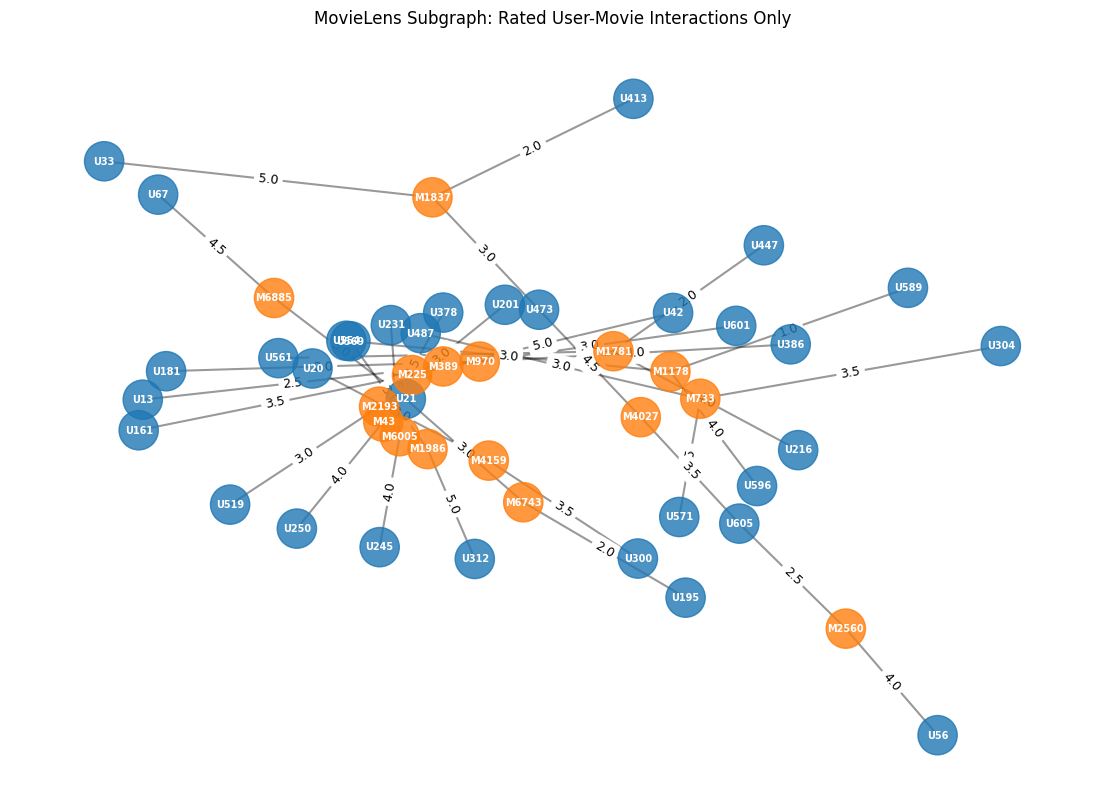

In [77]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
from torch_geometric.loader import LinkNeighborLoader

# 1. Create a small loader for visualization
small_loader = LinkNeighborLoader(
    data=train_data,
    num_neighbors=[3, 2],
    edge_label_index=(("user", "rates", "movie"), train_data["user", "rates", "movie"].edge_label_index),
    batch_size=4,
    shuffle=True,
)

batch = next(iter(small_loader))

# 2. Convert to NetworkX
homo_data = batch.to_homogeneous()
G = to_networkx(homo_data, to_undirected=True)

# 3. Create Node Labels (Original User/Movie IDs)
node_labels_full = {}
user_ids = batch["user"].node_id.tolist()
movie_ids = batch["movie"].node_id.tolist()

for i in range(batch["user"].num_nodes):
    node_labels_full[i] = f"U{user_ids[i]}"

for i in range(batch["movie"].num_nodes):
    node_labels_full[i + batch["user"].num_nodes] = f"M{movie_ids[i]}"

# 4. Extract rating labels for edges
edge_labels = {}
edge_index = batch["user", "rates", "movie"].edge_index
original_edge_indices = batch["user", "rates", "movie"].e_id
all_ratings = data["user", "rates", "movie"].rating_values

user_offset = 0
movie_offset = batch["user"].num_nodes

for i in range(edge_index.size(1)):
    u, v = int(edge_index[0, i] + user_offset), int(edge_index[1, i] + movie_offset)
    if G.has_edge(u, v):
        orig_idx = original_edge_indices[i]
        edge_labels[(u, v)] = f"{all_ratings[orig_idx].item():.1f}"

# 5. Filter graph to only include edges with ratings
rated_edges = list(edge_labels.keys())
G_filtered = G.edge_subgraph(rated_edges).copy()

# 6. Filter node labels to only include nodes present in the filtered graph
node_labels_filtered = {node: node_labels_full[node] for node in G_filtered.nodes()}

# 7. Define node colors (based on node types in the filtered graph)
node_colors = ['#1f77b4' if homo_data.node_type[n] == 0 else '#ff7f0e' for n in G_filtered.nodes()]

# 8. Plot using Kamada-Kawai layout
plt.figure(figsize=(14, 10))
pos = nx.kamada_kawai_layout(G_filtered)

nx.draw_networkx_nodes(G_filtered, pos, node_size=800, node_color=node_colors, alpha=0.8)
nx.draw_networkx_labels(G_filtered, pos, labels=node_labels_filtered, font_size=7, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G_filtered, pos, width=1.5, alpha=0.4)
nx.draw_networkx_edge_labels(G_filtered, pos, edge_labels=edge_labels, font_size=9)

plt.title("MovieLens Subgraph: Rated User-Movie Interactions Only")
plt.axis('off')
plt.show()

## Defining Edge-level Training Splits

Since our data is now ready-to-be-used, we can split the ratings of users into training, validation, and test splits.
This is needed in order to ensure that we leak no information about edges used during evaluation into the training phase.
For this, we make use of the [`transforms.RandomLinkSplit`](https://pytorch-geometric.readthedocs.io/en/latest/modules/transforms.html#torch_geometric.transforms.RandomLinkSplit) transformation from PyG.
This transforms randomly divides the edges in the `("user", "rates", "movie")` into training, validation and test edges.
The `disjoint_train_ratio` parameter further separates edges in the training split into edges used for message passing (`edge_index`) and edges used for supervision (`edge_label_index`).
Note that we also need to specify the reverse edge type `("movie", "rev_rates", "user")`.
This allows the `RandomLinkSplit` transform to drop reverse edges accordingly to not leak any information into the training phase.

In [8]:
# For this, we first split the set of edges into
# training (80%), validation (10%), and testing edges (10%).
# Across the training edges, we use 70% of edges for message passing,
# and 30% of edges for supervision.
# We further want to generate fixed negative edges for evaluation with a ratio of 2:1.
# Negative edges during training will be generated on-the-fly, so we don't want to
# add them to the graph right away.
# Overall, we can leverage the `RandomLinkSplit()` transform for this from PyG:
transform = T.RandomLinkSplit(
    num_val=0.1,  # 10% for validation
    num_test=0.1,  # 10% for testing
    disjoint_train_ratio=0.3,  # 30% of training edges for supervision
    neg_sampling_ratio=2.0,  # 2 negative edges for every positive edge in validation/test
    add_negative_train_samples=False,  # No negative edges added for training
    edge_types=("user", "rates", "movie"),
    rev_edge_types=("movie", "rev_rates", "user"),
)

train_data, val_data, test_data = transform(data)
print("Training data:")
print("==============")
print(train_data)
print()
print("Validation data:")
print("================")
print(val_data)
print("Test data:")
print("================")
print(test_data)


assert train_data["user", "rates", "movie"].num_edges == 56469
assert train_data["user", "rates", "movie"].edge_label_index.size(1) == 24201
assert train_data["movie", "rev_rates", "user"].num_edges == 56469
# No negative edges added:
assert train_data["user", "rates", "movie"].edge_label.min() == 1
assert train_data["user", "rates", "movie"].edge_label.max() == 1

assert val_data["user", "rates", "movie"].num_edges == 80670
assert val_data["user", "rates", "movie"].edge_label_index.size(1) == 30249
assert val_data["movie", "rev_rates", "user"].num_edges == 80670
# Negative edges with ratio 2:1:
assert val_data["user", "rates", "movie"].edge_label.long().bincount().tolist() == [20166, 10083]

Training data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 56469],
    edge_label=[24201],
    edge_label_index=[2, 24201],
  },
  (movie, rev_rates, user)={ edge_index=[2, 56469] }
)

Validation data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 80670],
    edge_label=[30249],
    edge_label_index=[2, 30249],
  },
  (movie, rev_rates, user)={ edge_index=[2, 80670] }
)
Test data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 90753],
    edge_label=[30249],
    edge_label_index=[2, 30249],
  },
  (movie, rev_rates, user)={ edge_index=[2, 90753] }
)


## Defining Mini-batch Loaders

We are now ready to create a mini-batch loader that will generate subgraphs that can be used as input into our GNN.
While this step is not strictly necessary for small-scale graphs, it is absolutely necessary to apply GNNs on larger graphs that do not fit onto GPU memory otherwise.
Here, we make use of the [`loader.LinkNeighborLoader`](https://pytorch-geometric.readthedocs.io/en/latest/modules/loader.html#torch_geometric.loader.LinkNeighborLoader) which samples multiple hops from both ends of a link and creates a subgraph from it.
Here, `edge_label_index` serves as the "seed links" to start sampling from.

In [9]:
# In the first hop, we sample at most 20 neighbors.
# In the second hop, we sample at most 10 neighbors.
# In addition, during training, we want to sample negative edges on-the-fly with
# a ratio of 2:1.
# We can make use of the `loader.LinkNeighborLoader` from PyG:
from torch_geometric.loader import LinkNeighborLoader

# Define seed edges:
edge_label_index = train_data["user", "rates", "movie"].edge_label_index
edge_label = train_data["user", "rates", "movie"].edge_label

train_loader = LinkNeighborLoader(
    data=train_data,
    num_neighbors=[20, 10],
    neg_sampling_ratio=2.0,
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)

# Inspect a sample:
sampled_data = next(iter(train_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() == 0
assert sampled_data["user", "rates", "movie"].edge_label.max() == 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[607],
    n_id=[607],
    num_sampled_nodes=[3],
  },
  movie={
    node_id=[2768],
    x=[2768, 20],
    n_id=[2768],
    num_sampled_nodes=[3],
  },
  (user, rates, movie)={
    edge_index=[2, 16910],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[16910],
    num_sampled_edges=[2],
    input_id=[128],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7701],
    e_id=[7701],
    num_sampled_edges=[2],
  }
)


## Creating a Heterogeneous Link-level GNN

We are now ready to create our heterogeneous GNN.
The GNN is responsible for learning enriched node representations from the surrounding subgraphs, which can be then used to derive edge-level predictions.
For defining our heterogenous GNN, we make use of [`nn.SAGEConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.SAGEConv) and the [`nn.to_hetero()`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.to_hetero_transformer.to_hetero) function, which transforms a GNN defined on homogeneous graphs to be applied on heterogeneous ones.

In addition, we define a final link-level classifier, which simply takes both node embeddings of the link we are trying to predict, and applies a dot-product on them.

As users do not have any node-level information, we choose to learn their features jointly via a `torch.nn.Embedding` layer. In order to improve the expressiveness of movie features, we do the same for movie nodes, and simply add their shallow embeddings to the pre-defined genre features.

In [10]:
from torch_geometric.nn import SAGEConv, to_hetero


class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()

        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

    def forward(self, x: Tensor, edge_index: Tensor) -> Tensor:
        # Define a 2-layer GNN computation graph.
        # Use a *single* `ReLU` non-linearity in-between.
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

# Our final classifier applies the dot-product between source and destination
# node embeddings to derive edge-level predictions:
class Classifier(torch.nn.Module):
    def forward(self, x_user: Tensor, x_movie: Tensor, edge_label_index: Tensor) -> Tensor:
        # Convert node embeddings to edge-level representations:
        edge_feat_user = x_user[edge_label_index[0]]
        edge_feat_movie = x_movie[edge_label_index[1]]

        # Apply dot-product to get a prediction per supervision edge:
        return (edge_feat_user * edge_feat_movie).sum(dim=-1)


class Model(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        # Since the dataset does not come with rich features, we also learn two
        # embedding matrices for users and movies:
        self.movie_lin = torch.nn.Linear(20, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)

        # Instantiate homogeneous GNN:
        self.gnn = GNN(hidden_channels)

        # Convert GNN model into a heterogeneous variant:
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())

        self.classifier = Classifier()

    def forward(self, data: HeteroData) -> Tensor:
        x_dict = {
          "user": self.user_emb(data["user"].node_id),
          "movie": self.movie_lin(data["movie"].x) + self.movie_emb(data["movie"].node_id),
        }

        # `x_dict` holds feature matrices of all node types
        # `edge_index_dict` holds all edge indices of all edge types
        x_dict = self.gnn(x_dict, data.edge_index_dict)

        pred = self.classifier(
            x_dict["user"],
            x_dict["movie"],
            data["user", "rates", "movie"].edge_label_index,
        )

        return pred


model = Model(hidden_channels=64)

print(model)

Model(
  (movie_lin): Linear(in_features=20, out_features=64, bias=True)
  (user_emb): Embedding(610, 64)
  (movie_emb): Embedding(9742, 64)
  (gnn): GraphModule(
    (conv1): ModuleDict(
      (user__rates__movie): SAGEConv(64, 64, aggr=mean)
      (movie__rev_rates__user): SAGEConv(64, 64, aggr=mean)
    )
    (conv2): ModuleDict(
      (user__rates__movie): SAGEConv(64, 64, aggr=mean)
      (movie__rev_rates__user): SAGEConv(64, 64, aggr=mean)
    )
  )
  (classifier): Classifier()
)


## Training a Heterogeneous Link-level GNN

Training our GNN is then similar to training any PyTorch model.
We move the model to the desired device, and initialize an optimizer that takes care of adjusting model parameters via stochastic gradient descent.

The training loop then iterates over our mini-batches, applies the forward computation of the model, computes the loss from ground-truth labels and obtained predictions (here we make use of binary cross entropy), and adjusts model parameters via back-propagation and stochastic gradient descent.

In [11]:
import tqdm
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: '{device}'")

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(1, 6):
    total_loss = total_examples = 0
    for sampled_data in tqdm.tqdm(train_loader):
        optimizer.zero_grad()

        # Move `sampled_data` to the respective `device`
        sampled_data = sampled_data.to(device)
        # Run `forward` pass of the model
        pred = model(sampled_data)
        # Apply binary cross entropy via
        # `F.binary_cross_entropy_with_logits(pred, ground_truth)`
        ground_truth = sampled_data["user", "rates", "movie"].edge_label
        loss = F.binary_cross_entropy_with_logits(pred, ground_truth)

        loss.backward()
        optimizer.step()
        total_loss += float(loss) * pred.numel()
        total_examples += pred.numel()
    print(f"Epoch: {epoch:03d}, Loss: {total_loss / total_examples:.4f}")

Device: 'cuda'


  0%|          | 0/190 [00:00<?, ?it/s]/tmp/ipykernel_1467/183054910.py:26: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(loss) * pred.numel()
100%|██████████| 190/190 [00:04<00:00, 47.41it/s]


Epoch: 001, Loss: 0.4435


100%|██████████| 190/190 [00:03<00:00, 51.80it/s]


Epoch: 002, Loss: 0.3508


...

Epoch: 003, Loss: 0.3291


100%|██████████| 190/190 [00:03<00:00, 55.40it/s]


Epoch: 004, Loss: 0.3168


100%|██████████| 190/190 [00:01<00:00, 122.30it/s]

Epoch: 005, Loss: 0.3024


## Evaluating a Heterogeneous Link-level GNN

After training, we evaluate our model on useen data coming from the validation set.
For this, we define a new `LinkNeighborLoader` (which now iterates over the edges in the validation set), obtain the predictions on validation edges by running the model, and finally evaluate the performance of the model by computing the AUC score over the set of predictions and their corresponding ground-truth edges (including both positive and negative edges).

In [32]:
# Define the validation seed edges:
edge_label_index = val_data["user", "rates", "movie"].edge_label_index
print(edge_label_index)
edge_label = val_data["user", "rates", "movie"].edge_label
print(edge_label)

val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=3 * 128,
    shuffle=False,
)

sampled_data = next(iter(val_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

sampled_data = next(iter(val_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data["movie"]["node_id"])


assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() >= 0
assert sampled_data["user", "rates", "movie"].edge_label.max() <= 1

tensor([[ 598,   49,  168,  ...,   50,  118,  190],
        [1734, 9212, 3233,  ..., 1515,  275, 8700]])
tensor([1., 1., 1.,  ..., 0., 0., 0.])
Sampled mini-batch:
HeteroData(
  user={
    node_id=[607],
    n_id=[607],
    num_sampled_nodes=[3],
  },
  movie={
    node_id=[2644],
    x=[2644, 20],
    n_id=[2644],
    num_sampled_nodes=[3],
  },
  (user, rates, movie)={
    edge_index=[2, 19264],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[19264],
    num_sampled_edges=[2],
    input_id=[384],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7624],
    e_id=[7624],
    num_sampled_edges=[2],
  }
)
Sampled mini-batch:
tensor([   4,   12,   15,  ..., 7445, 7989, 8696])


In [20]:
val_loader.data

HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 80670],
    edge_label=[30249],
    edge_label_index=[2, 30249],
  },
  (movie, rev_rates, user)={ edge_index=[2, 80670] }
)

In [31]:
from sklearn.metrics import roc_auc_score

preds = []
ground_truths = []
for sampled_data in tqdm.tqdm(val_loader):
    with torch.no_grad():
        # Collect predictions and ground-truths and write them into
        # `preds` and `ground_truths`.
        sampled_data = sampled_data.to(device)
        pred = model(sampled_data).sigmoid()
        ground_truth = sampled_data["user", "rates", "movie"].edge_label
        preds.append(pred)
        ground_truths.append(ground_truth)
        break

pred = torch.cat(preds, dim=0).cpu().numpy()
print(">> ", pred[0:3])
ground_truth = torch.cat(ground_truths, dim=0).cpu().numpy()
print(ground_truth[0:3])
auc = roc_auc_score(ground_truth, pred)
print(f"Validation AUC: {auc:.4f}")

  0%|          | 0/79 [00:00<?, ?it/s]

>>  [0.8903792 0.578219  0.6218454]
[1. 1. 1.]
Validation AUC: nan



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [82]:
import torch

# Set the model to evaluation mode
model.eval()

# 1. Pick an example from the test set
test_edge_index = test_data["user", "rates", "movie"].edge_label_index
user_idx = test_edge_index[0, 0].item()
movie_idx = test_edge_index[1, 0].item()
true_label = test_data["user", "rates", "movie"].edge_label[0].item()

# 2. Retrieve the actual rating value for this edge if it exists in the original data
# We check the original 'data' object using the mapped indices
mask = (data["user", "rates", "movie"].edge_index[0] == user_idx) & (data["user", "rates", "movie"].edge_index[1] == movie_idx)
edge_value = "N/A (Negative Sample)"
if mask.any():
    edge_value = data["user", "rates", "movie"].rating_values[mask][0].item()

# 3. Prepare the data for the model
with torch.no_grad():
    test_data = test_data.to(device)
    out = model(test_data)
    prediction_logit = out[0]
    probability = torch.sigmoid(prediction_logit).item()

print(f"--- Link Prediction Example ---")
print(f"User Index: {user_idx}")
print(f"Movie Index: {movie_idx}")
print(f"Actual Edge Rating Value: {edge_value}")
print(f"True Label (1=Edge exists, 0=No edge): {true_label}")
print(f"Predicted Probability: {probability:.4f}")

if probability > 0.5:
    print("Model Prediction: This user is LIKELY to rate this movie.")
else:
    print("Model Prediction: This user is UNLIKELY to rate this movie.")

--- Link Prediction Example ---
User Index: 138
Movie Index: 3819
Actual Edge Rating Value: 3.0
True Label (1=Edge exists, 0=No edge): 1.0
Predicted Probability: 0.6946
Model Prediction: This user is LIKELY to rate this movie.


#Node classification

In [84]:
from torch_geometric.nn import SAGEConv, to_hetero
import torch.nn.functional as F

# 1. Prepare Node Classification Labels (Predicting the first genre of a movie)
# Convert multi-hot genres back to a single label (index of the first 1)
movie_labels = movie_feat.argmax(dim=1)
num_classes = genres.shape[1]
data["movie"].y = movie_labels

# 2. Split nodes for training/validation/testing
num_nodes = data["movie"].num_nodes
indices = torch.randperm(num_nodes)

data["movie"].train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data["movie"].train_mask[indices[:int(num_nodes * 0.7)]] = True

data["movie"].val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data["movie"].val_mask[indices[int(num_nodes * 0.7):int(num_nodes * 0.85)]] = True

data["movie"].test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data["movie"].test_mask[indices[int(num_nodes * 0.85):]] = True

# 3. Define the Node Classification GNN
class NodeGNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), out_channels)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {key: self.conv1(x, edge_index_dict[edge_type]).relu()
                  for key, x in x_dict.items() for edge_type in edge_index_dict}
        return x_dict

class HeteroNodeClassifier(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_lin = torch.nn.Linear(20, hidden_channels)

        self.gnn = GNN(hidden_channels) # Reusing existing GNN structure from previous cells
        self.gnn = to_hetero(self.gnn, data.metadata())

        self.classifier = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x_dict = {
            "user": self.user_emb(data["user"].node_id),
            "movie": self.movie_lin(data["movie"].x)
        }

        x_dict = self.gnn(x_dict, data.edge_index_dict)
        return self.classifier(x_dict["movie"])

# 4. Training loop
model_nc = HeteroNodeClassifier(hidden_channels=64, out_channels=num_classes).to(device)
optimizer_nc = torch.optim.Adam(model_nc.parameters(), lr=0.01)
data_nc = data.to(device)

model_nc.train()
for epoch in range(1, 51):
    optimizer_nc.zero_grad()
    out = model_nc(data_nc)
    loss = F.cross_entropy(out[data_nc["movie"].train_mask], data_nc["movie"].y[data_nc["movie"].train_mask])
    loss.backward()
    optimizer_nc.step()

    if epoch % 10 == 0:
        model_nc.eval()
        pred = model_nc(data_nc).argmax(dim=-1)
        acc = (pred[data_nc["movie"].val_mask] == data_nc["movie"].y[data_nc["movie"].val_mask]).sum() / data_nc["movie"].val_mask.sum()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Acc: {acc:.4f}')
        model_nc.train()

Epoch: 010, Loss: 1.1327, Val Acc: 0.7070
Epoch: 020, Loss: 0.3139, Val Acc: 0.9199
Epoch: 030, Loss: 0.1027, Val Acc: 0.9658
Epoch: 040, Loss: 0.0355, Val Acc: 0.9884
Epoch: 050, Loss: 0.0103, Val Acc: 0.9945


In [85]:
# 5. Prediction Example
model_nc.eval()
with torch.no_grad():
    # Get predictions for all movies
    out = model_nc(data_nc)
    pred = out.argmax(dim=-1)

    # Pick a random movie from the test set
    test_indices = data_nc["movie"].test_mask.nonzero(as_tuple=True)[0]
    sample_idx = test_indices[0].item()

    actual_label = data_nc["movie"].y[sample_idx].item()
    predicted_label = pred[sample_idx].item()

    genre_names = genres.columns.tolist()
    print(f"\n--- Node Classification Example ---")
    print(f"Movie Index: {sample_idx}")
    print(f"Actual Genre: {genre_names[actual_label]}")
    print(f"Predicted Genre: {genre_names[predicted_label]}")


--- Node Classification Example ---
Movie Index: 28
Actual Genre: Adventure
Predicted Genre: Adventure


In [86]:
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

# 1. Load the MUTAG dataset (Collection of graphs)
dataset = TUDataset(root='/tmp/MUTAG', name='MUTAG')
dataset = dataset.shuffle()

train_dataset = dataset[:150]
test_dataset = dataset[150:]

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Define the Graph Classification Model
class GraphGNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GraphGNN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer: Pool node features into a single graph-level vector
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x

model_gc = GraphGNN(hidden_channels=64)
optimizer_gc = torch.optim.Adam(model_gc.parameters(), lr=0.01)
criterion_gc = torch.nn.CrossEntropyLoss()

# 3. Training Loop
def train():
    model_gc.train()
    for data in train_loader:
        optimizer_gc.zero_grad()
        out = model_gc(data.x, data.edge_index, data.batch)
        loss = criterion_gc(out, data.y)
        loss.backward()
        optimizer_gc.step()

# 4. Evaluation Function
def test(loader):
    model_gc.eval()
    correct = 0
    for data in loader:
        out = model_gc(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)

print("Training Graph Classification Model on MUTAG...")
for epoch in range(1, 101):
    train()
    if epoch % 20 == 0:
        train_acc = test(train_loader)
        test_acc = test(test_loader)
        print(f'Epoch: {epoch:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

Processing...
Done!


Training Graph Classification Model on MUTAG...
Epoch: 020, Train Acc: 0.7600, Test Acc: 0.6842
Epoch: 040, Train Acc: 0.7800, Test Acc: 0.7105
Epoch: 060, Train Acc: 0.8067, Test Acc: 0.7105
Epoch: 080, Train Acc: 0.7933, Test Acc: 0.7105
Epoch: 100, Train Acc: 0.8267, Test Acc: 0.6842


In [87]:
# 5. Prediction Example for Graph Classification
model_gc.eval()
with torch.no_grad():
    # Pick the first graph from the test set
    sample_graph = test_dataset[0]

    # Forward pass
    # Note: For a single graph, batch should be all zeros
    batch = torch.zeros(sample_graph.x.shape[0], dtype=torch.long)
    out = model_gc(sample_graph.x, sample_graph.edge_index, batch)
    pred = out.argmax(dim=1).item()
    actual = sample_graph.y.item()

    print(f"--- Graph Classification Example (MUTAG) ---")
    print(f"Graph Nodes: {sample_graph.num_nodes}")
    print(f"Graph Edges: {sample_graph.num_edges}")
    print(f"Actual Class: {actual}")
    print(f"Predicted Class: {pred}")

    if pred == actual:
        print("Result: Correct Prediction!")
    else:
        print("Result: Incorrect Prediction.")

--- Graph Classification Example (MUTAG) ---
Graph Nodes: 19
Graph Edges: 44
Actual Class: 1
Predicted Class: 1
Result: Correct Prediction!


### 6. Graph Classification on MovieLens (Commudity detection)
In this section, we treat each movie and its local neighbors (users) as an independent graph. Our goal is to classify the entire subgraph into a genre category.

In [90]:
from torch_geometric.data import Data
import torch.nn.functional as F

# 1. Create a list of subgraphs (one for each movie)
movie_subgraphs = []

# To keep it fast, we'll take the first 500 movies
for m_idx in range(500):
    edge_mask = data["user", "rates", "movie"].edge_index[1] == m_idx
    user_indices = data["user", "rates", "movie"].edge_index[0][edge_mask]

    if len(user_indices) == 0: continue

    m_f = movie_feat[m_idx].unsqueeze(0)
    u_f = torch.zeros((len(user_indices), 20))
    x = torch.cat([m_f, u_f], dim=0)

    local_u = torch.arange(1, len(user_indices) + 1)
    local_m = torch.zeros_like(local_u)
    edge_index = torch.stack([local_u, local_m], dim=0)

    y = movie_labels[m_idx].unsqueeze(0)
    movie_subgraphs.append(Data(x=x, edge_index=edge_index, y=y))

import random
random.shuffle(movie_subgraphs)
train_m_graphs = movie_subgraphs[:400]
test_m_graphs = movie_subgraphs[400:]

m_train_loader = DataLoader(train_m_graphs, batch_size=32, shuffle=True)
m_test_loader = DataLoader(test_m_graphs, batch_size=32, shuffle=False)

# 3. Fix: Initialize GraphGNN with input_dim=20 to match movie_feat
class MovieGraphGNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(MovieGraphGNN, self).__init__()
        self.conv1 = GCNConv(20, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, 20) # 20 genres

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin(x)

model_movie_gc = MovieGraphGNN(hidden_channels=64).to(device)
opt_mgc = torch.optim.Adam(model_movie_gc.parameters(), lr=0.01)

print(f"Created {len(movie_subgraphs)} movie subgraphs. Training model...")

for epoch in range(1, 31):
    model_movie_gc.train()
    for batch in m_train_loader:
        batch = batch.to(device)
        opt_mgc.zero_grad()
        out = model_movie_gc(batch.x, batch.edge_index, batch.batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        opt_mgc.step()

    if epoch % 10 == 0:
        model_movie_gc.eval()
        correct = 0
        for batch in m_test_loader:
            batch = batch.to(device)
            out = model_movie_gc(batch.x, batch.edge_index, batch.batch)
            correct += int((out.argmax(dim=1) == batch.y).sum())
        print(f"Epoch {epoch:02d}, Test Acc: {correct/len(test_m_graphs):.4f}")

Created 500 movie subgraphs. Training model...
Epoch 10, Test Acc: 0.5000
Epoch 20, Test Acc: 0.5800
Epoch 30, Test Acc: 0.6300


In [91]:
# 4. Movie Subgraph Prediction Example
model_movie_gc.eval()
with torch.no_grad():
    # Use the movie title from the actual index in the dataframe
    sample = test_m_graphs[0].to(device)
    batch = torch.zeros(sample.x.shape[0], dtype=torch.long).to(device)
    out = model_movie_gc(sample.x, sample.edge_index, batch)
    pred = out.argmax(dim=1).item()
    actual = sample.y.item()

    print(f"--- Movie Subgraph Classification ---")
    # Note: Using the first movie's title for demonstration purposes
    print(f"Users in Subgraph: {sample.num_nodes - 1}")
    print(f"Actual Genre: {genre_names[actual]}")
    print(f"Predicted Genre: {genre_names[pred]}")

    if pred == actual:
        print("Result: Correct Prediction!")
    else:
        print("Result: Incorrect Prediction.")

--- Movie Subgraph Classification ---
Users in Subgraph: 7
Actual Genre: Comedy
Predicted Genre: Comedy
Result: Correct Prediction!
